In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.Data import * 
from Triangle.Cosmology import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")

np.random.seed(114514)

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


## Mission settings 

In [2]:
MISSION = "Taiji"
if MISSION == "Taiji": 
    nominal_arm = 3e9 
    acc_noise_budget = 3e-15 
    oms_noise_budget = 8e-12 
    orbit_dir = "../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB"
    orbit_dt = DAY 
elif MISSION == "LISA": 
    pass 

## Data settings 

In [3]:
Tobs = 15. * DAY # data length in s 
t_start = 0. * DAY # start time in s
t_end = t_start + Tobs # end time in s 
dt = 20. # time cadance in s 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
Tobs = int(Tobs/dt) * dt 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 50): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*C/4./nominal_arm)<i*3e-4)[0] # the 0.3mHz window is an empirical value
    mask[mask_idx] = False 

# remove the frequencies below sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((31976,), (32401,))

## Model settings 

### Orbit model 

In [4]:
orbit = Orbit(
    OrbitDir=orbit_dir, 
    dt=orbit_dt, 
)

### Waveform model 

In [5]:
WFG = WaveformGeneratorFRef(
    mode="primary", # "primary" for 22 mode only 
)

### TDI Response model and settings 

In [6]:
FDTDI = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

response_kwargs_interp = dict(
    fmin=data_frequencies[-1], # used to calculate freq grid
    fmax=data_frequencies[0], # used to calculate freq grid
    fref=1e-3, # used to set reference point 
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=t_start/DAY, # minimum time of orbit in day 
    tmax=t_end/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tref is the defined at detector center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
)

response_kwargs_direct = dict(
    fref=1e-3, # used to set reference point 
    modes=[(2, 2)], 
    tmin=t_start/DAY, # minimum time of orbit in day 
    tmax=t_end/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tref is the defined at detector center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    interpolation_method=None, 
)

channel_names = ["A", "E", "T"]
channel_colors = [RED, BLUE, ORANGE]

### Noise model 

In [7]:
# set detector noise model 
PSDfunc = TDIPSDs(
    sacc=acc_noise_budget, 
    sro=oms_noise_budget, 
    L=nominal_arm, 
) 

# average over observation times to get noise CSD 
psd_a = np.zeros_like(data_frequencies)
psd_e = np.zeros_like(data_frequencies)
psd_t = np.zeros_like(data_frequencies)
noise_times = np.linspace(t_start, t_end, int(Tobs/DAY))
for itime in tqdm(range(len(noise_times))):
    arms = dict()
    for key in MOSA_labels: 
        arms[key] = orbit.LTTfunctions()[key](noise_times[itime])
    psd_a += PSDfunc.PSD_A2_unequal(data_frequencies, arms)
    psd_e += PSDfunc.PSD_E2_unequal(data_frequencies, arms)
    psd_t += PSDfunc.PSD_T2_unequal(data_frequencies, arms)
psd_a *= 1. / len(noise_times)
psd_e *= 1. / len(noise_times)
psd_t *= 1. / len(noise_times)
psd_channels = np.array([psd_a, psd_e, psd_t])

# noise-othorgonal approximation
csd_ae = np.zeros_like(psd_a)
csd_et = np.zeros_like(psd_a)
csd_ta = np.zeros_like(psd_a)

# noise orthogonal assumption 
covmatrix = np.array([
    [psd_a, csd_ae, np.conjugate(csd_ta)], 
    [np.conjugate(csd_ae), psd_e, csd_et], 
    [csd_ta, np.conjugate(csd_et), psd_t],
]) / 4. / delta_f # (3, 3, Nf)

inv_covmatrix = np.linalg.inv(np.transpose(covmatrix, axes=(2, 0, 1))) # (Nf, 3, 3)
# set the 3-3 element to 0 so that T channel will not be used in likelihood calculation
inv_covmatrix[:, 2, 2] *= 0. 

100%|██████████| 15/15 [00:00<00:00, 32.43it/s]


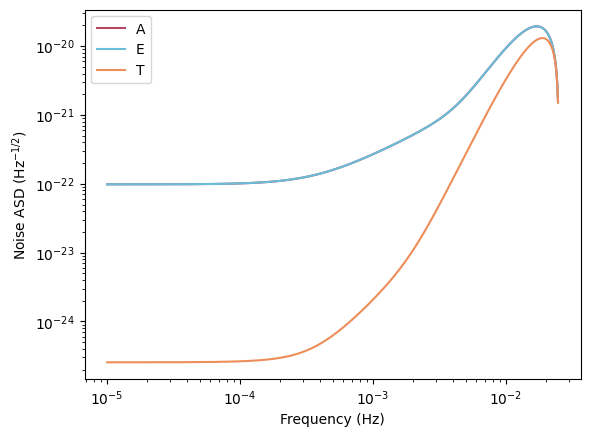

In [8]:
for i in range(3): 
    plt.loglog(data_frequencies, np.sqrt(psd_channels[i]), label=channel_names[i], color=channel_colors[i])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Noise ASD "+r'$({\rm Hz^{-1/2}})$')
plt.legend(loc="upper left")

## Data Generation 

In [9]:
mbhb_parameters = {
    'chirp_mass': 1527693.2821010326, # solar mass, redshifted 
    'mass_ratio': 0.6060083963754411,
    'spin_1z': 0.4, 
    'spin_2z': -0.6,
    'reference_time': 10.927959071370836, # day 
    'reference_phase': 2.1563629722527997, # rad 
    'luminosity_distance': 22016.264842325963, # mpc 
    'inclination': 1.9340646499796517, # rad 
    'longitude': 3.279277442759269, # rad, ecliptic 
    'latitude': 0.9176152704924524, # rad, ecliptic 
    'psi': 1.988850127130235 # rad 
    }

data_channels = FDTDI.Response(
    mbhb_parameters, 
    data_frequencies, 
    **response_kwargs_direct, 
)

snr = FrequencyDomainCovarianceSNR(data_channels, inv_covmatrix)
print("signal-to-noise ratio is", snr)

signal-to-noise ratio is 2392.5825236569995


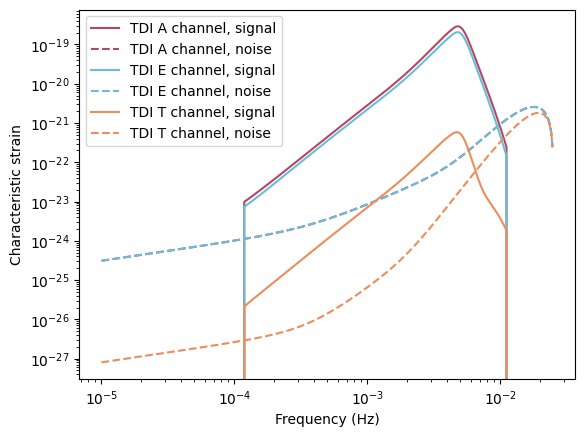

In [10]:
for i in range(3): 
    plt.loglog(data_frequencies, np.abs(data_channels[i]) * 2. * data_frequencies, label="TDI "+channel_names[i]+" channel, signal", color=channel_colors[i])
    plt.loglog(data_frequencies, np.sqrt(psd_channels[i] * data_frequencies), label="TDI "+channel_names[i]+" channel, noise", color=channel_colors[i], linestyle="--")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic strain")
plt.legend(loc="upper left")

## Fisher analysis 

In [11]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        param_dict, 
        frequencies,  
        **response_kwargs_interp, 
    )
    return res

# set initial steps for FIM calculation 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.01,
    'reference_phase': 0.01,
    'luminosity_distance': 100.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=mbhb_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequencies, 
    inverse_covariance=inv_covmatrix,
    verbose=0
)
FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 325.08646738237854,
 'mass_ratio': 0.004111140036982344,
 'spin_1z': 0.016068386795764535,
 'spin_2z': 0.03190124191397526,
 'reference_time': 1.1541939294743961e-05,
 'reference_phase': 0.02874592123539699,
 'luminosity_distance': 1286.6642310738198,
 'inclination': 0.01652894166213986,
 'longitude': 0.03879968965733254,
 'latitude': 0.02107539908640367,
 'psi': 0.021399744072147838}

## Parameter estimation with bilby 

In [12]:
import bilby 

### prior

In [13]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=mbhb_parameters["chirp_mass"]-10.*FIM.param_errors["chirp_mass"], maximum=mbhb_parameters["chirp_mass"]+10.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, mbhb_parameters["mass_ratio"]-10.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, mbhb_parameters["mass_ratio"]+10.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=-0.9, maximum=0.9, name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=-0.9, maximum=0.9, name="spin_1z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=mbhb_parameters["reference_time"]-10.*FIM.param_errors["reference_time"], maximum=mbhb_parameters["reference_time"]+10.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(6e3, mbhb_parameters["luminosity_distance"]-10.*FIM.param_errors["luminosity_distance"]), maximum=min(1e5, mbhb_parameters["luminosity_distance"]+10.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

# estimate_parameters = ["chirp_mass", "mass_ratio"]
estimate_parameters = ["longitude", "latitude", "psi"]
for param_name in priors.keys(): 
    if param_name in estimate_parameters: 
        pass 
    else: 
        priors[param_name] = mbhb_parameters[param_name]
        
priors

{'chirp_mass': 1527693.2821010326,
 'mass_ratio': 0.6060083963754411,
 'spin_1z': 0.4,
 'spin_2z': -0.6,
 'reference_time': 10.927959071370836,
 'reference_phase': 2.1563629722527997,
 'luminosity_distance': 22016.264842325963,
 'inclination': 1.9340646499796517,
 'longitude': Uniform(minimum=0.0, maximum=6.283185307179586, name='longitude', latex_label='$\\lambda$', unit=None, boundary='periodic'),
 'latitude': Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='latitude', latex_label='$\\beta$', unit=None, boundary=None),
 'psi': Uniform(minimum=0.0, maximum=3.141592653589793, name='psi', latex_label='$\\psi$', unit=None, boundary='periodic')}

### Likelihood
$${\rm ln} \mathcal{L}(\theta) = -\frac{1}{2}(d - h(\theta) | d - h(\theta))$$

In [14]:
Like_interp = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=inv_covmatrix, 
    response_parameters=response_kwargs_interp, 
    Fref_waveform=True, 
    use_gpu=False, 
    verbose=0
)

Like_direct = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=inv_covmatrix, 
    response_parameters=response_kwargs_direct, 
    Fref_waveform=True, 
    use_gpu=False, 
    verbose=0
)

fiducial_parameters = ParamDict2ParamArrFref(mbhb_parameters)
Like_direct.prepare_het_log_like(base_parameters=fiducial_parameters)

100%|██████████| 101/101 [00:04<00:00, 22.29it/s]


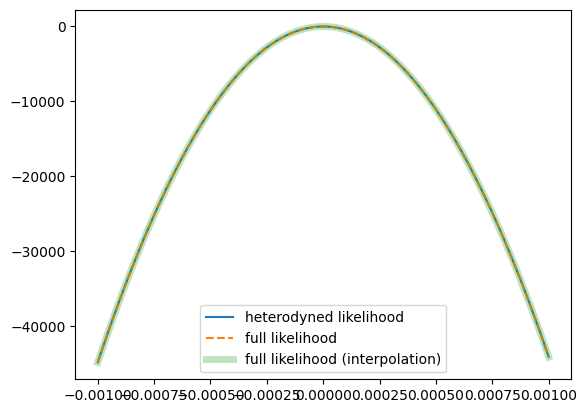

In [15]:
N_test = 101 
test_param_dev = np.linspace(-1e-3, 1e-3, N_test)
ll_het = [] 
ll_full = [] 
ll_full_interp = [] 
for i in tqdm(range(N_test)):
    test_param = np.array(fiducial_parameters).copy() 
    test_param[0] += test_param_dev[i]
    ll_het.append(Like_direct.het_log_like(test_param))
    ll_full.append(Like_direct.full_log_like(test_param))
    ll_full_interp.append(Like_interp.full_log_like(test_param))
ll_het = np.array(ll_het)
ll_full = np.array(ll_full)
ll_full_interp = np.array(ll_full_interp)
ll_het = ll_het - np.max(ll_het)
ll_full = ll_full - np.max(ll_full)
ll_full_interp = ll_full_interp - np.max(ll_full_interp)
plt.plot(test_param_dev, ll_het, linestyle="-", label="heterodyned likelihood")
plt.plot(test_param_dev, ll_full, linestyle="--", label="full likelihood")
plt.plot(test_param_dev, ll_full, linestyle="-", label="full likelihood (interpolation)", linewidth=5, alpha=0.3)
plt.legend()

100%|██████████| 101/101 [00:04<00:00, 22.01it/s]


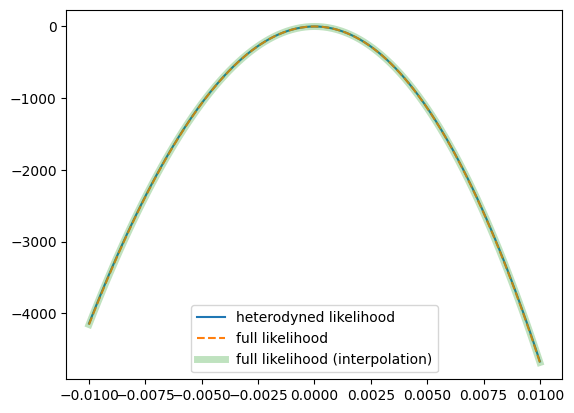

In [16]:
N_test = 101 
test_param_dev = np.linspace(-1e-2, 1e-2, N_test)
ll_het = [] 
ll_full = [] 
ll_full_interp = [] 
for i in tqdm(range(N_test)):
    test_param = np.array(fiducial_parameters).copy() 
    test_param[1] += test_param_dev[i]
    ll_het.append(Like_direct.het_log_like(test_param))
    ll_full.append(Like_direct.full_log_like(test_param))
    ll_full_interp.append(Like_interp.full_log_like(test_param))
ll_het = np.array(ll_het)
ll_full = np.array(ll_full)
ll_full_interp = np.array(ll_full_interp)
ll_het = ll_het - np.max(ll_het)
ll_full = ll_full - np.max(ll_full)
ll_full_interp = ll_full_interp - np.max(ll_full_interp)
plt.plot(test_param_dev, ll_het, linestyle="-", label="heterodyned likelihood")
plt.plot(test_param_dev, ll_full, linestyle="--", label="full likelihood")
plt.plot(test_param_dev, ll_full, linestyle="-", label="full likelihood (interpolation)", linewidth=5, alpha=0.3)
plt.legend()

In [17]:
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="full"):
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        
        if type == "full":
            self.likelihood = Like_interp.full_log_like 
        elif type == "het": 
            self.likelihood = Like_direct.het_log_like
        else: 
            raise ValueError("wrong likelihood type.")

    def log_likelihood(self):
        return self.likelihood(ParamDict2ParamArrFref(self.parameters))

In [18]:
BLike_het = bilby_likelihood_wrapper(type="het")

In [19]:
import multiprocessing
ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result_het = bilby.run_sampler(
    likelihood=BLike_het, 
    priors=priors,
    # sampler="nessai", 
    sampler="dynesty", 
    nlive=500, # dynesty / nessai 
    walks=20, # dynesty 
    nact=50, # dynesty 
    maxmcmc=2000, # dynesty 
    # stopping=0.1, # nessai 
    dlogz=0.1, # dynesty 
    npool=ncpu, # use all cpus 
    injection_parameters=mbhb_parameters, 
    outdir="../../Samples",
    label="tribbh_example_2d_het",
    plot=True,
    resume=False, 
    # resume=True, 
)

21:15 bilby INFO    : Running for label 'tribbh_example_2d_het', output will be saved to '../../Samples'
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))


number of cpus = 12


21:15 bilby INFO    : Analysis priors:
21:15 bilby INFO    : longitude=Uniform(minimum=0.0, maximum=6.283185307179586, name='longitude', latex_label='$\\lambda$', unit=None, boundary='periodic')
21:15 bilby INFO    : latitude=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='latitude', latex_label='$\\beta$', unit=None, boundary=None)
21:15 bilby INFO    : psi=Uniform(minimum=0.0, maximum=3.141592653589793, name='psi', latex_label='$\\psi$', unit=None, boundary='periodic')
21:15 bilby INFO    : chirp_mass=1527693.2821010326
21:15 bilby INFO    : mass_ratio=0.6060083963754411
21:15 bilby INFO    : spin_1z=0.4
21:15 bilby INFO    : spin_2z=-0.6
21:15 bilby INFO    : reference_time=10.927959071370836
21:15 bilby INFO    : reference_phase=2.1563629722527997
21:15 bilby INFO    : luminosity_distance=22016.264842325963
21:15 bilby INFO    : inclination=1.9340646499796517
21:15 bilby INFO    : Analysis likelihood class: <class '__main__.bilby_likelihood_wrapper'>
21:15 bil

1it [00:00, ?it/s]

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/dynesty/sampler.py:761: UserWarning: The sampling was stopped short due to maxiter/maxcall limit the delta(log(z)) criterion is not achieved; posterior may be poorly sampled
  warnings.warn('The sampling was stopped short due to'
21:24 bilby INFO    : Written checkpoint file ../../Samples/tribbh_example_2d_het_resume.pickle
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/dynesty/plotting.py:786: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0., max(y0) * 1.05])
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/dynesty/plotting.py:786: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0., max(y0) * 1.05])
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/dynesty/plotting.py:

SystemExit: 130

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


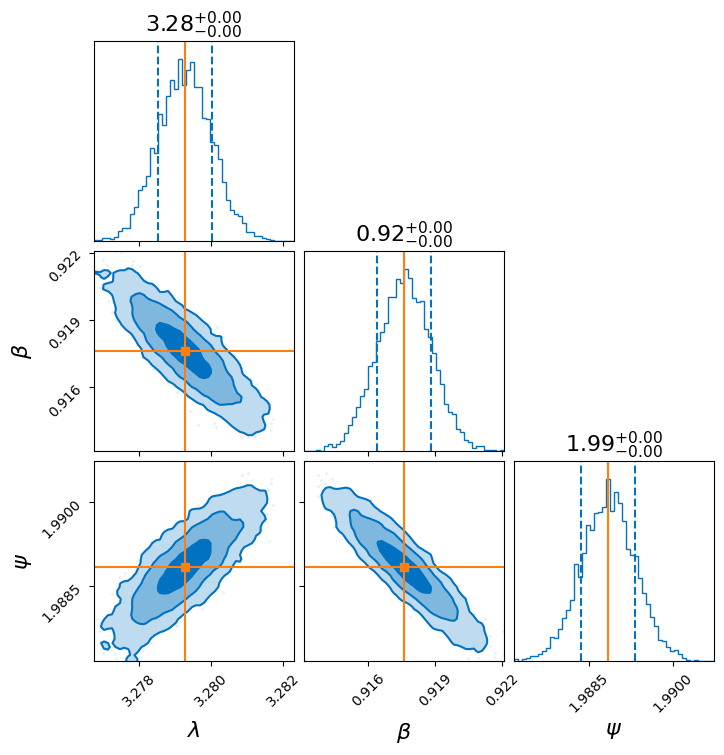

In [ ]:
result_het.plot_corner(save=True)

In [ ]:
BLike_full = bilby_likelihood_wrapper(type="full")

In [ ]:
result_full = bilby.run_sampler(
    likelihood=BLike_full, 
    priors=priors,
    # sampler="nessai", 
    sampler="dynesty", 
    nlive=500, # dynesty / nessai 
    walks=20, # dynesty 
    nact=50, # dynesty 
    maxmcmc=2000, # dynesty 
    # stopping=0.1, # nessai 
    dlogz=0.1, # dynesty 
    npool=ncpu, # use all cpus 
    injection_parameters=mbhb_parameters, 
    outdir="../../Samples",
    label="tribbh_example_2d_full",
    plot=True,
    resume=False, 
    # resume=True, 
)

21:07 bilby INFO    : Running for label 'tribbh_example_2d_full', output will be saved to '../../Samples'
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
21:07 bilby INFO    : Analysis priors:
21:07 bilby INFO    : longitude=Uniform(minimum=0.0, maximum=6.283185307179586, name='longitude', latex_label='$\\lambda$', unit=None, boundary='periodic')
21:07 bilby INFO    : latitude=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='latitude', latex_label='$\\beta$', unit=None, boundary=None)
21:07 bilby INFO    : psi=Uniform(minimum=0.0, maximum=3.141592653589793, name='psi', latex_label='$\\psi$', unit=None, boundary='periodic')
21:07 bilby INFO    : chirp_mass=1527693.2821010326


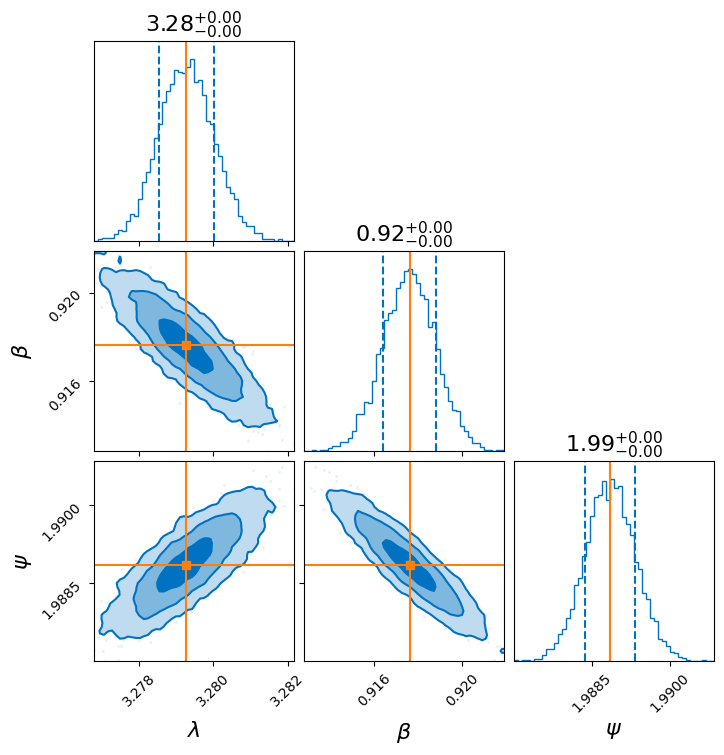

In [ ]:
result_full.plot_corner(save=True)